โหลดข้อมูลสำเร็จ!


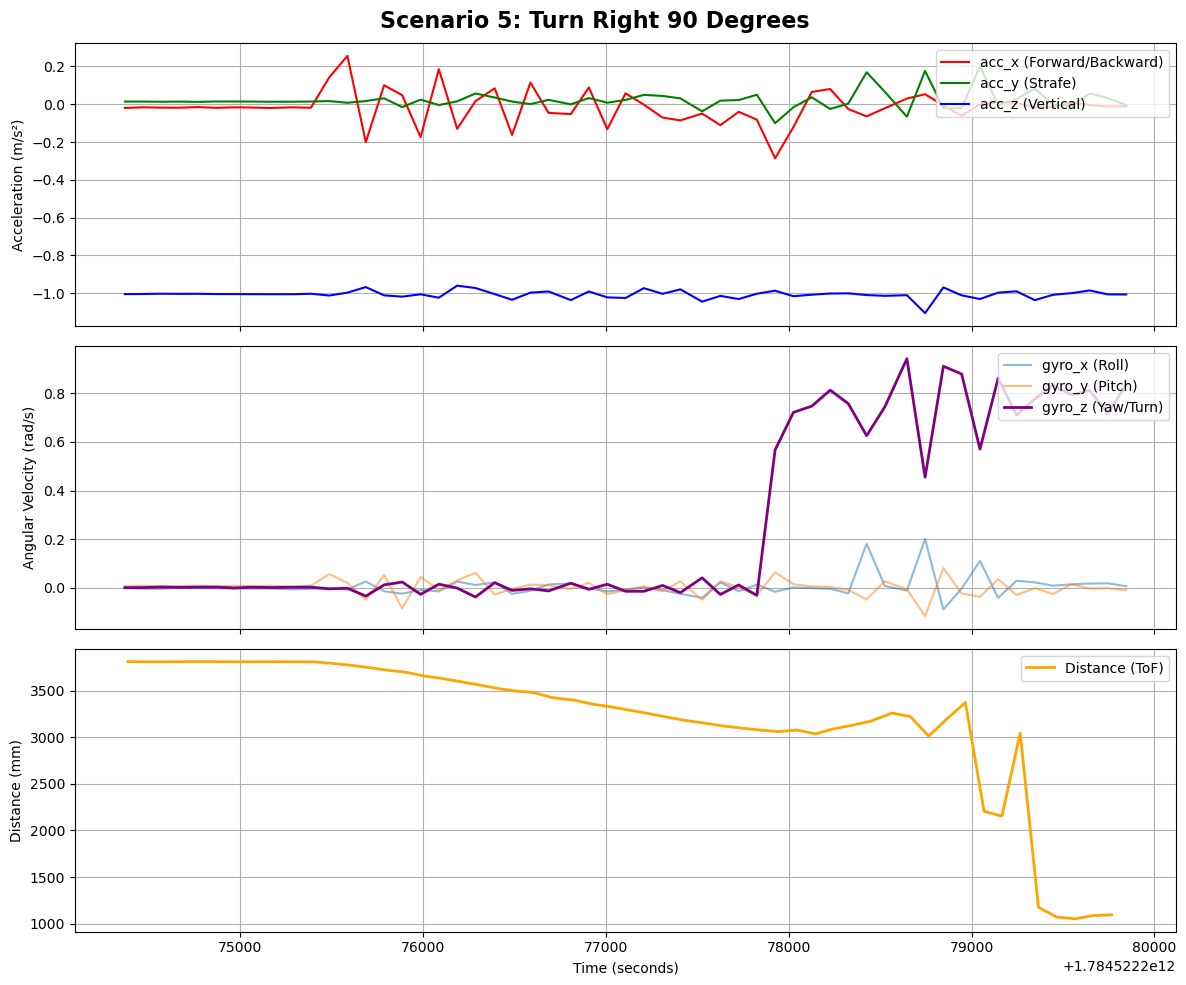

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# หมายเหตุ: ในขั้นตอนจริง ให้ตัดแบ่งข้อมูลใน CSV แยกตามช่วงเวลาของแต่ละสถานการณ์ 
# หรืออ่านไฟล์แยก (หากตอนเก็บข้อมูลแยกไฟล์ไว้ เช่น acc_scenario1.csv)

try:
    # โหลดข้อมูลจากไฟล์ CSV
    df_acc = pd.read_csv('/Users/nannam/Downloads/classwork4/sit5/ACC.csv')
    df_gyro = pd.read_csv('/Users/nannam/Downloads/classwork4/sit5/GYRO.csv')
    df_dist = pd.read_csv('/Users/nannam/Downloads/classwork4/sit5/Distance.csv')
    
    print("โหลดข้อมูลสำเร็จ!")
except FileNotFoundError:
    print("กรุณาตรวจสอบว่าไฟล์ CSV อยู่ในโฟลเดอร์เดียวกันกับตัว Notebook หรือไม่")

# ---------------------------------------------------------------------
# ฟังก์ชันสําหรับพล็อตกราฟเปรียบเทียบในแต่ละสถานการณ์
# ---------------------------------------------------------------------
def plot_scenario_analysis(scenario_title, t_start, t_end):
    """
    ฟังก์ชันสำหรับตัดช่วงเวลา (Slice) และพล็อตกราฟ IMU & Distance คู่กัน
    t_start: เวลาเริ่มต้นของสถานการณ์ (วินาที)
    t_end: เวลาสิ้นสุดของสถานการณ์ (วินาที)
    """
    # เลือกช่วงข้อมูลตามเวลา
    acc_slice = df_acc[(df_acc['Time'] >= t_start) & (df_acc['Time'] <= t_end)]
    gyro_slice = df_gyro[(df_gyro['Time'] >= t_start) & (df_gyro['Time'] <= t_end)]
    dist_slice = df_dist[(df_dist['Time'] >= t_start) & (df_dist['Time'] <= t_end)]
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(scenario_title, fontsize=16, fontweight='bold')
    
    # 1. พล็อตกราฟ ความเร่ง (Acceleration)
    axes[0].plot(acc_slice['Time'], acc_slice['acc_x'], label='acc_x (Forward/Backward)', color='red')
    axes[0].plot(acc_slice['Time'], acc_slice['acc_y'], label='acc_y (Strafe)', color='green')
    axes[0].plot(acc_slice['Time'], acc_slice['acc_z'], label='acc_z (Vertical)', color='blue')
    axes[0].set_ylabel('Acceleration (m/s²)')
    axes[0].grid(True)
    axes[0].legend(loc='upper right')
    
    # 2. พล็อตกราฟ ความเร็วเชิงมุม (Gyroscope)
    axes[1].plot(gyro_slice['Time'], gyro_slice['gyro_x'], label='gyro_x (Roll)', alpha=0.5)
    axes[1].plot(gyro_slice['Time'], gyro_slice['gyro_y'], label='gyro_y (Pitch)', alpha=0.5)
    axes[1].plot(gyro_slice['Time'], gyro_slice['gyro_z'], label='gyro_z (Yaw/Turn)', color='purple', linewidth=2)
    axes[1].set_ylabel('Angular Velocity (rad/s)')
    axes[1].grid(True)
    axes[1].legend(loc='upper right')
    
    # 3. พล็อตกราฟ ระยะทาง (Distance Sensor)
    axes[2].plot(dist_slice['Time'], dist_slice['Distance(mm.)'], label='Distance (ToF)', color='orange', linewidth=2)
    axes[2].set_ylabel('Distance (mm)')
    axes[2].set_xlabel('Time (seconds)')
    axes[2].grid(True)
    axes[2].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

plot_scenario_analysis("Scenario 5: Turn Right 90 Degrees", df_acc['Time'].min(), df_acc['Time'].max())